In [12]:
import os
import copy
import matplotlib.pyplot as plt
import math

In [13]:
def read_graph(filename):
    with open(filename, 'r') as f:
        n = int(f.readline())
        adj = {}
        for i in range(n):
            row = list(map(int, f.readline().split()))
            adj[i] = {j for j in range(n) if row[j] == 1}
    return n, adj

In [14]:
def rm_v(adj, v):
    """Remove v; return (v, neighbors) so we can restore."""
    nbrs = adj.pop(v)
    for u in nbrs:
        adj[u].discard(v)
    return (v, nbrs)

def restore_v(adj, saved):
    v, nbrs = saved
    adj[v] = nbrs
    for u in nbrs:
        adj[u].add(v)

def rm_vs(adj, vertices):
    return [rm_v(adj, v) for v in vertices]

def restore_vs(adj, saved_list):
    # Restore in reverse order (in case any were neighbors of each other)
    for s in reversed(saved_list):
        restore_v(adj, s)

In [15]:
counter = 0
def r0(adj):
    global counter
    counter += 1
    if not adj:
        return 0

    isolated = [v for v in adj if not adj[v]]
    if isolated:
        saved = rm_vs(adj, isolated)
        result = len(isolated) + r0(adj)
        restore_vs(adj, saved)
        return result

    v = max(adj, key=lambda v: len(adj[v]))

    # Branch 1: take v
    saved1 = rm_vs(adj, [v] + list(adj[v]))
    val_take = 1 + r0(adj)
    restore_vs(adj, saved1)

    # Branch 2: drop v
    saved2 = rm_v(adj, v)
    val_drop = r0(adj)
    restore_v(adj, saved2)

    return max(val_take, val_drop)

In [21]:
def r1(adj):
    global counter
    counter += 1

    if not adj:
        return 0

    isolated = [v for v in adj if not adj[v]]
    if isolated:
        saved = rm_vs(adj, isolated)
        result = len(isolated) + r1(adj)
        restore_vs(adj, saved)
        return result

    for v in adj:
        if len(adj[v]) == 1:
            u = next(iter(adj[v]))
            saved = rm_vs(adj, [v, u])
            result = 1 + r1(adj)
            restore_vs(adj, saved)
            return result

    v = max(adj, key=lambda v: len(adj[v]))

    nbrs = list(adj[v])
    saved1 = rm_vs(adj, [v] + nbrs)
    val_take = 1 + r1(adj)
    restore_vs(adj, saved1)

    saved2 = rm_v(adj, v)
    val_drop = r1(adj)
    restore_v(adj, saved2)

    return max(val_take, val_drop)

In [ ]:
def r2(adj):
    global counter
    counter += 1

    if not adj:
        return 0

    # Rule 0: isolated vertices
    isolated = [v for v in adj if not adj[v]]
    if isolated:
        saved = rm_vs(adj, isolated)
        result = len(isolated) + r2(adj)
        restore_vs(adj, saved)
        return result

    # Rule 1: degree-1
    for v in adj:
        if len(adj[v]) == 1:
            u = next(iter(adj[v]))
            saved = rm_vs(adj, [v, u])
            result = 1 + r2(adj)
            restore_vs(adj, saved)
            return result

    # Rule 2: degree-2
    for v in adj:
        if len(adj[v]) == 2:
            u, w = tuple(adj[v])
            if w in adj[u]:
                # Triangle: take v, delete N[v]
                saved = rm_vs(adj, [v, u, w])
                result = 1 + r2(adj)
                restore_vs(adj, saved)
                return result
            else:
                # Fold: delete v,u,w; add z connected to (N(u)∪N(w))\{v}
                new_nbrs = (adj[u] | adj[w]) - {v, u, w}
                saved = rm_vs(adj, [v, u, w])
                z = ("z", id(saved))  # any fresh label
                while z in adj:
                    z = ("z", id(saved), len(adj))
                adj[z] = set(new_nbrs)
                for x in new_nbrs:
                    adj[x].add(z)
                result = 1 + r2(adj)
                # Undo fold: remove z, then restore v,u,w
                for x in new_nbrs:
                    adj[x].discard(z)
                del adj[z]
                restore_vs(adj, saved)
                return result

    # Branching: max-degree v
    v = max(adj, key=lambda v: len(adj[v]))

    # Branch 1: take v, remove N[v]
    saved1 = rm_vs(adj, [v] + list(adj[v]))
    val_take = 1 + r2(adj)
    restore_vs(adj, saved1)

    # Branch 2: drop v
    saved2 = rm_v(adj, v)
    val_drop = r2(adj)
    restore_v(adj, saved2)

    return max(val_take, val_drop)

g30.in: n=30, MIS=14, calls=15376
g40.in: n=40, MIS=16, calls=145285
g50.in: n=50, MIS=19, calls=1083541
g60.in: n=60, MIS=20, calls=8312781


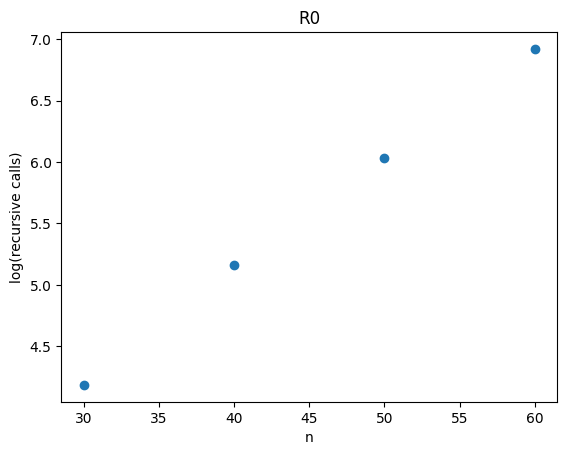

In [18]:
folder = 'lab2data/'
results = []


r0_files = ['g30.in', 'g40.in', 'g50.in','g60.in']
r1_files = ['g30.in', 'g40.in', 'g50.in','g60.in','g70.in','g80.in','g90.in','g100.in']
r2_files = ['g100.in',  'g120.in',  'g30.in',  'g40.in',  'g60.in',  'g80.in',
'g110.in',  'g4.in',   'g50.in', 'g70.in',  'g90.in']
for filename in r0_files:
    
    n, adj = read_graph(os.path.join(folder, filename))
    counter = 0
    mis = r0(adj)
    results.append((n, counter))
    print(f"{filename}: n={n}, MIS={mis}, calls={counter}")

sizes = [r[0] for r in results]
log_calls = [math.log10(r[1]) for r in results]

plt.scatter(sizes, log_calls)
plt.xlabel("n")
plt.ylabel("log(recursive calls)")
plt.title("R0")
plt.savefig("r1_calls.png")
plt.show()

R0 g30.in: n=30, MIS=14, calls=15376
R0 g40.in: n=40, MIS=16, calls=145285
R0 g50.in: n=50, MIS=19, calls=1083541
R0 g60.in: n=60, MIS=20, calls=8312781
R1 g30.in: n=30, MIS=14, calls=134
R1 g40.in: n=40, MIS=16, calls=1433
R1 g50.in: n=50, MIS=19, calls=5343
R1 g60.in: n=60, MIS=20, calls=32639
R1 g70.in: n=70, MIS=22, calls=139740
R1 g80.in: n=80, MIS=24, calls=578893
R1 g90.in: n=90, MIS=26, calls=1898952
R1 g100.in: n=100, MIS=27, calls=7922029
R2 g100.in: n=100, MIS=27, calls=1027164
R2 g120.in: n=120, MIS=30, calls=8627949
R2 g30.in: n=30, MIS=14, calls=32
R2 g40.in: n=40, MIS=16, calls=200
R2 g60.in: n=60, MIS=20, calls=5416
R2 g80.in: n=80, MIS=24, calls=83563
R2 g110.in: n=110, MIS=29, calls=2996790
R2 g4.in: n=4, MIS=2, calls=3
R2 g50.in: n=50, MIS=19, calls=1188
R2 g70.in: n=70, MIS=22, calls=22949
R2 g90.in: n=90, MIS=26, calls=250938


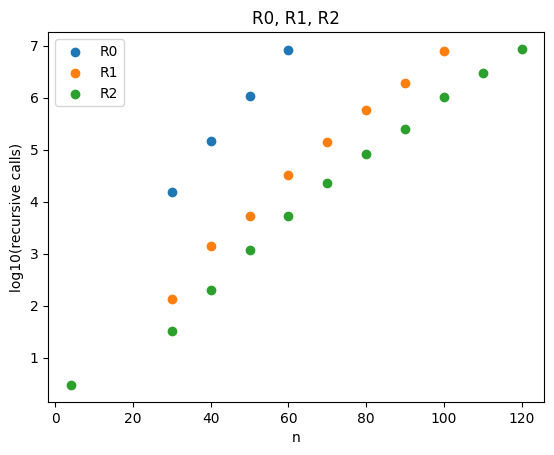

In [22]:

folder = 'lab2data/'
results = []


r0_files = ['g30.in', 'g40.in', 'g50.in','g60.in']
r1_files = ['g30.in', 'g40.in', 'g50.in','g60.in','g70.in','g80.in','g90.in','g100.in']
r2_files = ['g100.in',  'g120.in',  'g30.in',  'g40.in',  'g60.in',  'g80.in',
'g110.in',  'g4.in',   'g50.in', 'g70.in',  'g90.in']

r0_results = []
r1_results = []
r2_results = []
for filename in r0_files:
    n, adj = read_graph(os.path.join(folder, filename))
    counter = 0
    mis = r0(adj)
    r0_results.append((n, counter))
    print(f"R0 {filename}: n={n}, MIS={mis}, calls={counter}")

for filename in r1_files:
    n, adj = read_graph(os.path.join(folder, filename))
    counter = 0
    mis = r1(adj)
    r1_results.append((n, counter))
    print(f"R1 {filename}: n={n}, MIS={mis}, calls={counter}")

for filename in r2_files:
    n, adj = read_graph(os.path.join(folder, filename))
    counter = 0
    mis = r2(adj)
    r2_results.append((n, counter))
    print(f"R2 {filename}: n={n}, MIS={mis}, calls={counter}")


sizes0 = [r[0] for r in r0_results]
calls0 = [math.log10(r[1]) for r in r0_results]

sizes1 = [r[0] for r in r1_results]
calls1 = [math.log10(r[1]) for r in r1_results]

sizes2 = [r[0] for r in r2_results]
calls2 = [math.log10(r[1]) for r in r2_results]


plt.scatter(sizes0, calls0, label="R0")
plt.scatter(sizes1, calls1, label="R1")
plt.scatter(sizes2, calls2, label="R2")

plt.xlabel("n")
plt.ylabel("log10(recursive calls)")
plt.title("R0, R1, R2")
plt.legend()
plt.savefig("calls.png")
plt.show()